# Load Data

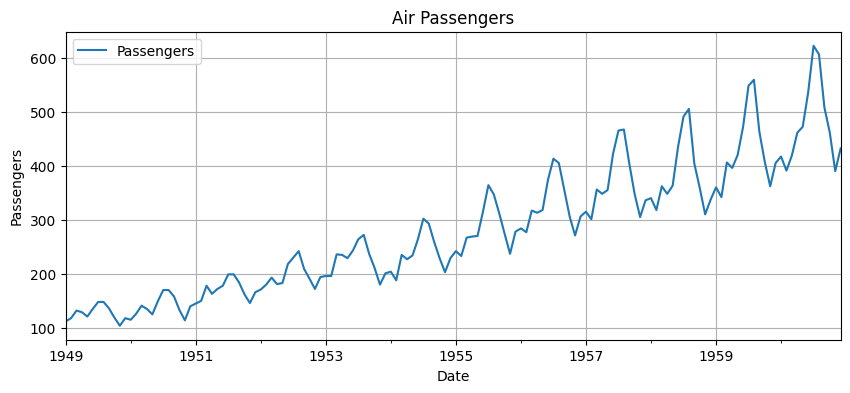

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", module="statsmodels")


# Load the AirPassengers dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')

# Visualize the series
df.plot(figsize=(10, 4), title="Air Passengers")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.grid()
plt.show()

# Split Data

In [2]:
def create_time_series_features(data, lookback_window=12):
    """
    Create features for time series forecasting using lagged values
    """
    X, y = [], []
    
    for i in range(lookback_window, len(data)):
        # Use previous 'lookback_window' values as features
        X.append(data[i-lookback_window:i])
        y.append(data[i])
    
    return np.array(X), np.array(y)

In [3]:
lag = 12
X = df['Passengers'][:-lag]
y = df['Passengers'][lag:]

# Define sizes
n = len(X)
train_size = int(n * 0.7)
val_size = int(n * 0.15)
test_size = n - train_size - val_size

# Split the series
X_train = X[:train_size]
y_train = y[:train_size]
X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]
X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]

# Confirm sizes
print(f"Train starts on: {X_train.index[0]}, Train ends on: {X_train.index[-1]}")
print(f"Validation starts on: {X_val.index[0]}, Validation ends on: {X_val.index[-1]}")
print(f"Test starts on: {X_test.index[0]}, Test ends on: {X_test.index[-1]}")
print(f"Train size: {len(X_train)}, Val size: {len(X_val)}, Test size: {len(X_test)}")

Train starts on: 1949-01-01 00:00:00, Train ends on: 1956-08-01 00:00:00
Validation starts on: 1956-09-01 00:00:00, Validation ends on: 1958-03-01 00:00:00
Test starts on: 1958-04-01 00:00:00, Test ends on: 1959-12-01 00:00:00
Train size: 92, Val size: 19, Test size: 21


In [4]:
from sklearn.preprocessing import StandardScaler

# Scale the features
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(np.array(X_train).reshape(-1,1))
X_val_scaled = scaler_X.transform(np.array(X_val).reshape(-1,1))
y_train_scaled = scaler_y.fit_transform(np.array(y_train).reshape(-1, 1)).ravel()
y_val_scaled = scaler_y.transform(np.array(y_val).reshape(-1, 1)).ravel()


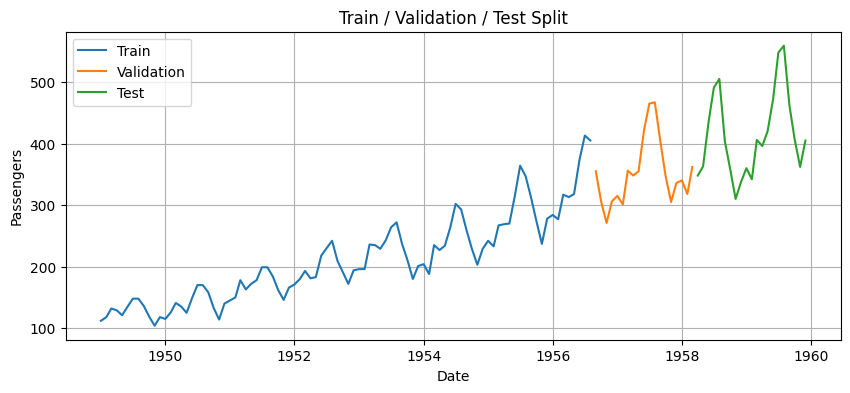

In [5]:
plt.figure(figsize=(10, 4))
plt.plot(X_train, label="Train")
plt.plot(X_val, label="Validation")
plt.plot(X_test, label="Test")
plt.title("Train / Validation / Test Split")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.legend()
plt.grid()
plt.show()

# Base Models

In [6]:
from abc import ABC, abstractmethod
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
from copy import deepcopy

class AbstractBaseModel (ABC):

    def __init__(self, model, hparams, *args, **kwagrs):
        self.model = model
        self.hparams = hparams
        self.fitness_score = 0.0
        self.forecast = None

    @abstractmethod
    def train(self, X_train, y_train):
        raise NotImplementedError("Subclasses must implement train method")

    @abstractmethod
    def predict(self, X_test):
        raise NotImplementedError("Subclasses must implement predict method")

    @abstractmethod
    def get_name(self):
        raise NotImplementedError("Subclasses must implement get_name method")
    
    @abstractmethod
    def crossover(self, other):
        raise NotImplementedError("Subclasses must implement crossover method")

    @abstractmethod
    def mutate(self):
        raise NotImplementedError("Subclasses must implement mutate method")
    
    def calculate_fitness(self, pred, y_test, diversity_score):
        alpha = 0.9
        beta = 0.1
        self.fitness_score = (alpha * 1/(np.sqrt(mean_squared_error(y_test, pred)) + 1e-8)) + (beta * diversity_score)
        return self.fitness_score
    
    def __str__(self):
        return str(type(self).__name__) + ' ' + str(self.hparams) + ' Fitness: ' + str(self.fitness_score)
    
    def __repr__(self):
        return str(type(self).__name__) + ' ' + str(self.hparams) + ' Fitness: ' + str(self.fitness_score)


class SarimaModel(AbstractBaseModel):

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self._X_train = None  # cache training data for fallback retraining
    
    def train(self, X_train, y_train):
        self._X_train = X_train
        p = self.hparams['p']
        d = self.hparams['d']
        q = self.hparams['q']
        s = self.hparams['s']
        try:
            if s > 1:
                self.model = SARIMAX(
                    X_train, order=(p, d, q), seasonal_order=(p, d, q, s)
                ).fit(disp=False)
            else:
                # s=0 or s=1 means no seasonal component
                self.model = SARIMAX(X_train, order=(p, d, q)).fit(disp=False)
        except Exception:
            # Fallback to ARIMA(1,1,1) when the chosen params fail to converge
            self.hparams.update({'p': 1, 'd': 1, 'q': 1, 's': 0})
            self.model = SARIMAX(X_train, order=(1, 1, 1)).fit(disp=False)
    
    def predict(self, X_test):
        self.forecast = self.model.forecast(steps=len(X_test))
        return self.forecast
    
    @classmethod
    def get_name(cls):
        return 'sarima'
    
    def crossover(self, other):
        if not isinstance(other, SarimaModel):
            raise ValueError("Can only crossover with another SarimaModel")
        
        child1 = deepcopy(self)
        child2 = deepcopy(other)
        
        if np.random.random() < 0.5:
            child1.hparams['p'], child2.hparams['p'] = child2.hparams['p'], child1.hparams['p']
        if np.random.random() < 0.5:
            child1.hparams['d'], child2.hparams['d'] = child2.hparams['d'], child1.hparams['d']
        if np.random.random() < 0.5:
            child1.hparams['q'], child2.hparams['q'] = child2.hparams['q'], child1.hparams['q']
        if np.random.random() < 0.5:
            child1.hparams['s'], child2.hparams['s'] = child2.hparams['s'], child1.hparams['s']
        
        child1.fitness_score = 0.0
        child2.fitness_score = 0.0
        
        return child1, child2
    
    def mutate(self):
        mutation_param = np.random.choice(['p', 'd', 'q', 's'])
        
        if mutation_param == 'p':
            self.hparams['p'] = np.random.randint(0, 5)
        elif mutation_param == 'd':
            self.hparams['d'] = np.random.randint(0, 2)
        elif mutation_param == 'q':
            self.hparams['q'] = np.random.randint(0, 5)
        elif mutation_param == 's':
            # 0 means non-seasonal; consistent with init_population choices
            self.hparams['s'] = np.random.choice([0, 2, 3, 4, 6, 12])
        
        self.fitness_score = 0.0
        
        return self

class SVRModel (AbstractBaseModel):

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def train(self, X_train, y_train):
        kernel = self.hparams['kernel']
        c = self.hparams['c']
        gamma = self.hparams['gamma']
        epsilon = self.hparams['epsilon']
        self.model = SVR(kernel=kernel, C=c, gamma=gamma, epsilon=epsilon)
        self.model.fit(X_train, y_train)
    
    def predict(self, X_test):
        self.forecast = self.model.predict(X_test)
        return self.forecast
    
    @classmethod
    def get_name(cls):
        return 'svr'
    
    def crossover(self, other):
        if not isinstance(other, SVRModel):
            raise ValueError("Can only crossover with another SVRModel")
        
        child1 = deepcopy(self)
        child2 = deepcopy(other)
        
        if np.random.random() < 0.5:
            child1.hparams['kernel'], child2.hparams['kernel'] = child2.hparams['kernel'], child1.hparams['kernel']
        
        if np.random.random() < 0.5:
            alpha = np.random.random()
            c1, c2 = child1.hparams['c'], child2.hparams['c']
            child1.hparams['c'] = alpha * c1 + (1 - alpha) * c2
            child2.hparams['c'] = alpha * c2 + (1 - alpha) * c1
        
        if np.random.random() < 0.5:
            alpha = np.random.random()
            eps1, eps2 = child1.hparams['epsilon'], child2.hparams['epsilon']
            child1.hparams['epsilon'] = alpha * eps1 + (1 - alpha) * eps2
            child2.hparams['epsilon'] = alpha * eps2 + (1 - alpha) * eps1
        
        child1.fitness_score = 0.0
        child2.fitness_score = 0.0
        
        return child1, child2
    
    def mutate(self):
        
        # Randomly select which parameter to mutate
        mutation_param = np.random.choice(['kernel', 'c', 'epsilon'])
        
        if mutation_param == 'kernel':
            self.hparams['kernel'] = np.random.choice(["linear", "rbf", "poly"])
        
        elif mutation_param == 'c':
            current_c = self.hparams['c']
            noise = np.random.normal(0, current_c * 0.1)  # 10% noise
            self.hparams['c'] = max(0.1, min(100, current_c + noise))
        
        elif mutation_param == 'epsilon':
            current_eps = self.hparams['epsilon']
            noise = np.random.normal(0, current_eps * 0.1)  # 10% noise
            self.hparams['epsilon'] = max(0.001, min(0.5, current_eps + noise))

        self.fitness_score = 0.0
        
        return self
    
class MLPModel (AbstractBaseModel):

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def train(self, X_train, y_train):
        hidden_layer_sizes = self.hparams['hidden_layer_sizes']
        learning_rate = self.hparams['learning_rate']
        
        hidden_layer_sizes = (int(hidden_layer_sizes),)
        
        self.model = MLPRegressor(hidden_layer_sizes=hidden_layer_sizes,
                            learning_rate_init=learning_rate,
                            max_iter=500, random_state=42)
        self.model.fit(X_train, y_train)
    
    def predict(self, X_test):
        self.forecast = self.model.predict(X_test)
        return self.forecast
    
    @classmethod
    def get_name(cls):
        return 'mlp'
    
    def crossover(self, other):
        if not isinstance(other, MLPModel):
            raise ValueError("Can only crossover with another MLPModel")
        
        child1 = deepcopy(self)
        child2 = deepcopy(other)
        
        if np.random.random() < 0.5:
            alpha = np.random.random()
            h1, h2 = child1.hparams['hidden_layer_sizes'], child2.hparams['hidden_layer_sizes']
            child1.hparams['hidden_layer_sizes'] = int(alpha * h1 + (1 - alpha) * h2)
            child2.hparams['hidden_layer_sizes'] = int(alpha * h2 + (1 - alpha) * h1)
        
        if np.random.random() < 0.5:
            alpha = np.random.random()
            lr1, lr2 = child1.hparams['learning_rate'], child2.hparams['learning_rate']
            child1.hparams['learning_rate'] = alpha * lr1 + (1 - alpha) * lr2
            child2.hparams['learning_rate'] = alpha * lr2 + (1 - alpha) * lr1
        
        child1.fitness_score = 0.0
        child2.fitness_score = 0.0
        
        return child1, child2
    
    def mutate(self):
        
        # Randomly select which parameter to mutate
        mutation_param = np.random.choice(['hidden_layer_sizes', 'learning_rate'])
        
        if mutation_param == 'hidden_layer_sizes':
            current_size = self.hparams['hidden_layer_sizes']
            change = np.random.randint(-10, 11)  # Change by -10 to +10
            self.hparams['hidden_layer_sizes'] = max(5, min(50, current_size + change))
        
        elif mutation_param == 'learning_rate':
            current_lr = self.hparams['learning_rate']
            noise = np.random.normal(0, current_lr * 0.1)  # 10% noise
            self.hparams['learning_rate'] = max(0.001, min(0.1, current_lr + noise))

        self.fitness_score = 0.0
        
        return self

    
class EnsembleModel (AbstractBaseModel):

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def train(self, X_train, y_train):
        for model in self.hparams.keys():
            self.hparams[model].train(X_train, y_train)
    
    def predict(self, X_test):
        self.forecast = 0.0
        for model in self.hparams.keys():
            self.forecast += self.hparams[model].predict(X_test)
        self.forecast /= len(self.hparams.keys()) # Average of all predictions
        return self.forecast
    
    @classmethod
    def get_name(cls):
        return 'ensemble'
    
    def crossover(self, other):
        return self, other
    
    def mutate(self):
        return self


# Model Diversity and Evaluation

In [7]:
def print_population(population):
    for model in population.keys():
        for individual in population[model]:
            print(individual)
    print('============================\n\n')


def init_population(population_size, pool_of_models):
    population = {}

    for model in pool_of_models:
        population[model.get_name()] = []
        if model is SarimaModel:
            for _ in range(population_size):
                population[model.get_name()].append(
                    SarimaModel(
                        SARIMAX,
                        {
                            'p': np.random.randint(0, 5),
                            'd': np.random.randint(0, 2),
                            'q': np.random.randint(0, 5),
                            's': np.random.choice([0, 6, 12])
                        }
                    )
                )
        elif model is SVRModel:
            for _ in range(population_size):
                population[model.get_name()].append(
                    SVRModel(
                        SVR,
                        {
                            'kernel' : np.random.choice(["linear", "rbf", "poly"]),
                            'c' : np.random.uniform(0.1, 100),
                            'gamma': np.random.choice(['scale']),
                            'epsilon' : np.random.uniform(0.001, 0.5)
                        }
                    )
                )
        elif model is MLPModel:
            for _ in range(population_size):
                population[model.get_name()].append(
                    MLPModel(
                        MLPRegressor,
                        {
                            'hidden_layer_sizes': np.random.randint(5, 50),
                            'learning_rate': np.random.uniform(0.001, 0.1)
                        }
                    )
                )
    
    return population

In [8]:
from itertools import zip_longest


def individual_diversity(population, X_test):
    
    # Get predictions from all models
    model_predictions = {}
    model_names = []
    
    # print("Generating predictions from individual models...")
    for model in population.keys():
        model_names.append(model)
        model_predictions[model] = []
        for individual in population[model]:
            model_predictions[model].append(individual.predict(X_test))
    
    # Convert to numpy array for easier computation
    pred_matrix = [list(lst) for lst in zip_longest(*model_predictions.values(), fillvalue=None)]
    
    # Calculate pairwise disagreements using MSE
    n_rows, n_cols = np.shape(pred_matrix)[0:2]
    disagreement_matrix = np.zeros((n_rows, n_cols))

    for i in range(n_rows):  # For each model instance (row)
        for j in range(n_cols):  # For each model type (column)
            ref_pred = pred_matrix[i][j]
            mse_list = []
            for k in range(n_cols):
                if k != j:
                    comp_pred = pred_matrix[i][k]
                    mse = mean_squared_error(ref_pred, comp_pred)
                    mse_list.append(mse)
            disagreement_matrix[i][j] = np.mean(mse_list)
    
    return disagreement_matrix

In [9]:
def individual_evaluation_with_diversity(population, X_train, y_train, X_val, y_val):

    for model in population.keys():
        for individual in population[model]:
            individual.train(X_train, y_train)
            pred = individual.predict(X_val)
            # individual.calculate_fitness(pred, y_val)

    disagreement_matrix = individual_diversity(population, X_val)

    i = 0
    for model in population.keys():
        j = 0
        for individual in population[model]:
            pred = individual.predict(X_val)
            individual.calculate_fitness(pred, y_val, disagreement_matrix[j][i])
            j +=1
        i += 1


In [10]:
def individual_evaluation(population, X_train, y_train, X_val, y_val):

    for model in population.keys():
        for individual in population[model]:
            individual.train(X_train, y_train)
            pred = individual.predict(X_val)
            individual.calculate_fitness(pred, y_val)


In [11]:
from itertools import combinations


def calculate_model_diversity(models_dict, X_test):
    """
    Calculate disagreement measure (diversity) for ensemble models using MSE.
    
    Parameters:
    -----------
    models_dict : dict
        Dictionary with model names as keys and trained model objects as values
        Format: {'model_name': model_object, ...}
    X_test : array-like
        Test data for generating predictions
    
    Returns:
    --------
    float : Average disagreement measure across all model pairs
    dict : Dictionary with detailed diversity metrics and model predictions
    """
    
    if len(models_dict) < 2:
        raise ValueError("Need at least 2 models to calculate diversity")
    
    # Get predictions from all models
    model_predictions = {}
    model_names = []
    
    # print("Generating predictions from individual models...")
    for model_name, model_obj in models_dict.items():
        predictions = model_obj.predict(X_test)
        model_predictions[model_name] = predictions
        model_names.append(model_name)
        # print(f"  {model_name}: predictions generated")
    
    # Convert to numpy array for easier computation
    pred_matrix = np.column_stack([model_predictions[name] for name in model_names])
    n_models = len(model_names)
    
    # Calculate pairwise disagreements using MSE
    pairwise_disagreements = []
    disagreement_matrix = np.zeros((n_models, n_models))
    model_pairs = []
    
    # print("\nCalculating pairwise disagreements...")
    for i, j in combinations(range(n_models), 2):
        model_i = model_names[i]
        model_j = model_names[j]
        pred_i = pred_matrix[:, i]
        pred_j = pred_matrix[:, j]
        
        disagreement = mean_squared_error(pred_i, pred_j)
        pairwise_disagreements.append(disagreement)
        disagreement_matrix[i, j] = disagreement
        disagreement_matrix[j, i] = disagreement  # Symmetric matrix
        model_pairs.append((model_i, model_j))
        
        # print(f"  {model_i} vs {model_j}: MSE = {disagreement:.6f}")
    
    # Calculate overall diversity measure
    avg_disagreement = np.mean(pairwise_disagreements)
    
    # Additional diversity statistics
    diversity_stats = {
        'average_disagreement': avg_disagreement,
        'pairwise_disagreements': pairwise_disagreements,
        'disagreement_matrix': disagreement_matrix,
        'model_pairs': model_pairs,
        'min_disagreement': np.min(pairwise_disagreements),
        'max_disagreement': np.max(pairwise_disagreements),
        'std_disagreement': np.std(pairwise_disagreements),
        'n_pairs': len(pairwise_disagreements),
        'model_names': model_names,
        'individual_predictions': model_predictions
    }
    
    return avg_disagreement, diversity_stats

In [12]:
def plot_forecasts(models, actual, save_path=None, show=True, label=None):
    plt.figure(figsize=(10, 4))
    plt.plot(actual, label='Actual')
    for model in models:
        plt.plot(model.forecast, label=model.get_name())
    if label:
        plt.gca().text(0.02, 0.97, label, transform=plt.gca().transAxes,
                       fontsize=12, verticalalignment='top',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
    plt.grid()
    plt.legend(loc='upper right')
    if save_path:
        plt.savefig(save_path, dpi=100, bbox_inches='tight')
    if show:
        plt.show()
    else:
        plt.close()

In [13]:
def team_evaluation(population, X_test, y_test, plot=True, save_path=None, label=None):
    alpha = 0.9
    beta = 0.1

    best_models = {}
    for model in population.keys():
        best_ind = None
        for individual in population[model]:
            best_ind = individual if best_ind is None or individual.fitness_score > best_ind.fitness_score else best_ind
        best_models[best_ind.get_name()] = best_ind

    ensemble = EnsembleModel(None, best_models)
    pred = ensemble.predict(X_test)

    if plot or save_path:
        models_to_plot = best_models.copy()
        models_to_plot['ensemble'] = ensemble
        plot_forecasts(models_to_plot.values(), y_test, save_path=save_path, show=plot, label=label)

    diversity_score, _ = calculate_model_diversity(best_models, X_test)
    fitness_score = (alpha * (1 / (np.sqrt(mean_squared_error(pred, y_test) + 1e-8)))) + (beta * diversity_score)

    return fitness_score, best_models, pred, ensemble

# Genetic Algorithm Operators

In [14]:
from copy import deepcopy


def random_selection(population):
    selected_population = {}

    for model_type in population.keys():
        model_list = population[model_type]
        population_size = len(model_list)
        selected_population[model_type] = []

        for _ in range(population_size):
            random_index = np.random.choice(population_size)
            selected_population[model_type].append(deepcopy(model_list[random_index]))

    return selected_population


In [15]:
def crossover(population, crossover_rate=0.8):
    new_population = {}
    
    for model_type in population.keys():
        model_list = population[model_type]
        population_size = len(model_list)
        new_population[model_type] = []
        
        # Process pairs of individuals
        for i in range(0, population_size - 1, 2):
            parent1 = model_list[i]
            parent2 = model_list[i + 1]
            
            # Decide whether to perform crossover
            if np.random.random() < crossover_rate:
                # Use the crossover method of the object
                child1, child2 = parent1.crossover(parent2)
                new_population[model_type].extend([child1, child2])
            else:
                # No crossover, just copy parents
                new_population[model_type].extend([deepcopy(parent1), deepcopy(parent2)])
        
        # Handle odd population size
        if population_size % 2 == 1:
            new_population[model_type].append(deepcopy(model_list[-1]))
    
    return new_population

In [16]:
def mutation(population, mutation_rate=0.5):
    mutated_population = {}
    
    for model_type in population.keys():
        model_list = population[model_type]
        mutated_population[model_type] = []
        
        for individual in model_list:
            # Decide whether to mutate this individual
            if np.random.random() < mutation_rate:
                # Use the mutate method of the object
                mutated_individual = individual.mutate()
                mutated_population[model_type].append(mutated_individual)
            else:
                # No mutation, just copy the individual
                mutated_population[model_type].append(deepcopy(individual))
    
    return mutated_population

# Cooperative CoEvolutional Algorithm

In [17]:
import os
import glob
from PIL import Image
from sklearn.metrics import r2_score


model_constructors = {
    "sarima": (SarimaModel, SARIMAX),
    "svr":    (SVRModel, SVR),
    "mlp":    (MLPModel, MLPRegressor),
}


def run_single_experiment(pool_of_models, population_size=10, num_generations=100,
                          mutation_rate=0.5, early_stop_patience=15,
                          run_dir=None, show_plot=True, verbose=False):
    import warnings
    warnings.filterwarnings("ignore")

    if run_dir:
        os.makedirs(run_dir, exist_ok=True)

    _sx = StandardScaler()
    _sy = StandardScaler()
    _X_tr = _sx.fit_transform(np.array(X_train).reshape(-1, 1))
    _X_va = _sx.transform(np.array(X_val).reshape(-1, 1))
    _y_tr = _sy.fit_transform(np.array(y_train).reshape(-1, 1)).ravel()
    _y_va = _sy.transform(np.array(y_val).reshape(-1, 1)).ravel()

    population = init_population(population_size, pool_of_models)

    best_fitness = -np.inf
    no_improve = 0
    fitness_history = []

    for gen in range(num_generations):
        individual_evaluation_with_diversity(population, _X_tr, _y_tr, _X_va, _y_va)

        frame_path = os.path.join(run_dir, f"generation_{gen+1:03d}.png") if run_dir else None
        fitness_score, _, _, _ = team_evaluation(
            population, _X_va, _y_va, plot=False, save_path=frame_path,
            label=f"Generation {gen + 1}"
        )
        fitness_history.append({"generation": gen + 1, "fitness_score": fitness_score})

        if verbose:
            print(f"Generation {gen + 1}")
            for model_type, individuals in population.items():
                for ind in individuals:
                    print(f"  {ind}")
            print(f"  -> Team fitness: {fitness_score:.5f}")
            print()

        if fitness_score > best_fitness:
            best_fitness = fitness_score
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= early_stop_patience:
                if verbose:
                    print(f"Early stopping at generation {gen + 1}: no improvement for {early_stop_patience} generations.")
                break

        selected = random_selection(population)
        crossed  = crossover(selected)
        population = mutation(crossed, mutation_rate=mutation_rate)

    # Final evaluation after last mutation round
    individual_evaluation_with_diversity(population, _X_tr, _y_tr, _X_va, _y_va)

    best_models = {}
    for m in population:
        best_ind = max(population[m], key=lambda x: x.fitness_score)
        best_models[best_ind.get_name()] = best_ind

    # Fitness evolution plot
    fitness_df = pd.DataFrame(fitness_history)
    plt.figure(figsize=(10, 4))
    plt.plot(fitness_df["generation"], fitness_df["fitness_score"], marker="o", markersize=3)
    plt.title("Fitness evolution")
    plt.xlabel("Generation")
    plt.ylabel("Fitness score")
    plt.grid()
    if run_dir:
        fitness_df.to_csv(os.path.join(run_dir, "fitness_history.csv"), index=False)
        plt.savefig(os.path.join(run_dir, "fitness_evolution.png"), dpi=100, bbox_inches="tight")
    if show_plot:
        plt.show()
    else:
        plt.close()

    if run_dir:
        frame_paths = sorted(glob.glob(os.path.join(run_dir, "generation_*.png")))
        if frame_paths:
            frames = [Image.open(p).convert("RGB") for p in frame_paths]
            frames[0].save(
                os.path.join(run_dir, "evolution.gif"),
                save_all=True, append_images=frames[1:],
                duration=400, loop=0, optimize=False,
            )

    # Retrain on train+val, evaluate on test
    X_tv = pd.concat([X_train, X_val])
    y_tv = pd.concat([y_train, y_val])

    _sx2 = StandardScaler()
    _sy2 = StandardScaler()
    _X_tv = _sx2.fit_transform(np.array(X_tv).reshape(-1, 1))
    _X_te = _sx2.transform(np.array(X_test).reshape(-1, 1))
    _y_tv = _sy2.fit_transform(np.array(y_tv).reshape(-1, 1)).ravel()
    _y_te = _sy2.transform(np.array(y_test).reshape(-1, 1)).ravel()

    final_models = {}
    for name, m in best_models.items():
        cls, base_cls = model_constructors[name]
        inst = cls(base_cls, deepcopy(m.hparams))
        inst.train(_X_tv, _y_tv)
        final_models[name] = inst

    pred = EnsembleModel(None, final_models).predict(_X_te)
    pred_original = _sy2.inverse_transform(pred.reshape(-1, 1)).ravel()
    y_te_original = np.array(y_test)

    results = {
        "n_generations": len(fitness_history),
        "best_fitness":  best_fitness,
        "r2":            r2_score(_y_te, pred),
        "rmse":          np.sqrt(mean_squared_error(y_te_original, pred_original)),
        "mse":           mean_squared_error(y_te_original, pred_original),
    }

    if run_dir:
        pd.DataFrame([results]).to_csv(os.path.join(run_dir, "results.csv"), index=False)

    return results


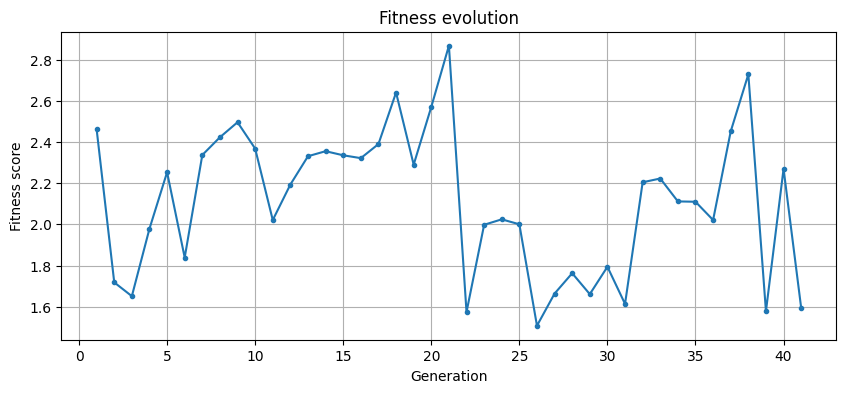

{'n_generations': 41, 'best_fitness': 2.8668869442496723, 'r2': 0.6097087027786174, 'rmse': 44.82054799576797, 'mse': 2008.88152264094}


In [18]:
pool_of_models = [SarimaModel, SVRModel, MLPModel]

result = run_single_experiment(
    pool_of_models,
    population_size=10,
    num_generations=100,
    mutation_rate=0.2,
    early_stop_patience=20,
    run_dir='runs_random/single_run'
)
print(result)


# Repeated Experiments & Statistical Analysis

Running 20 independent experiments → runs_random/


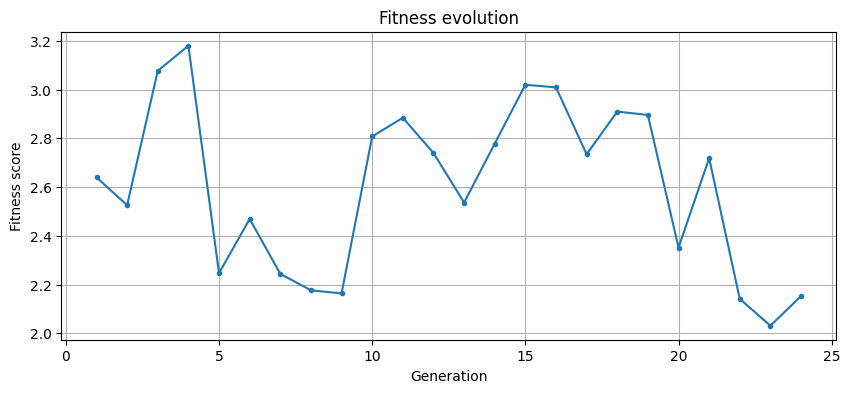

  Run  1/20  gens= 24  R²=0.6146  RMSE=44.5412


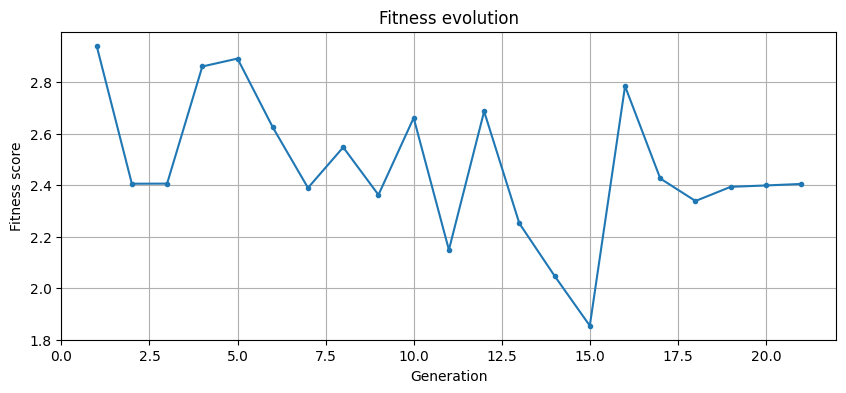

  Run  2/20  gens= 21  R²=0.6898  RMSE=39.9600


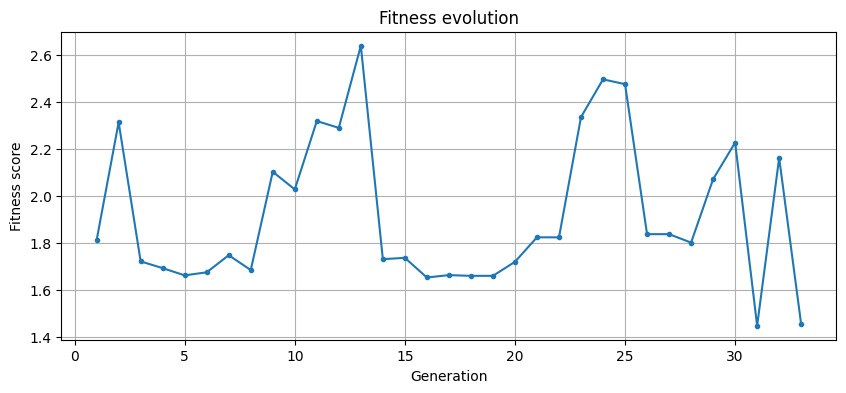

  Run  3/20  gens= 33  R²=0.7702  RMSE=34.3903


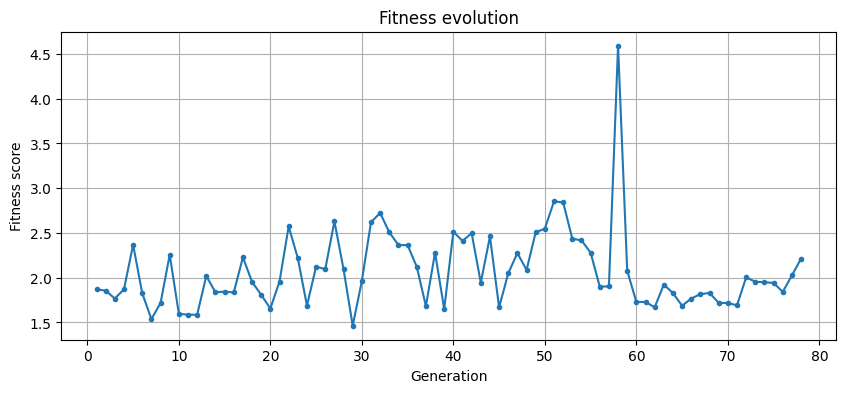

  Run  4/20  gens= 78  R²=0.2417  RMSE=62.4743


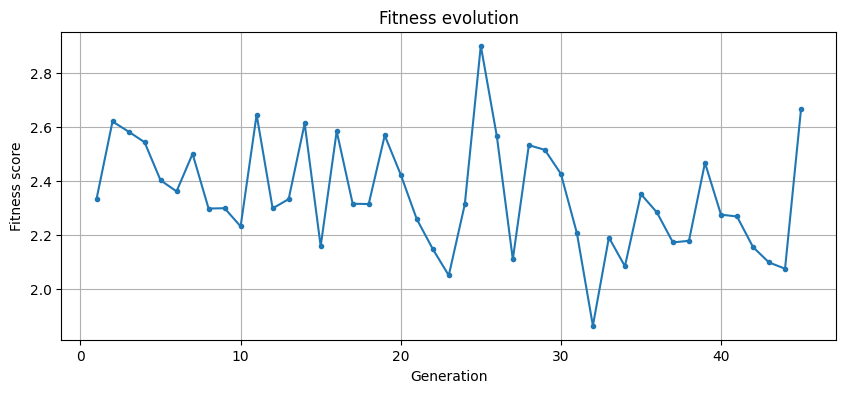

  Run  5/20  gens= 45  R²=0.5833  RMSE=46.3097


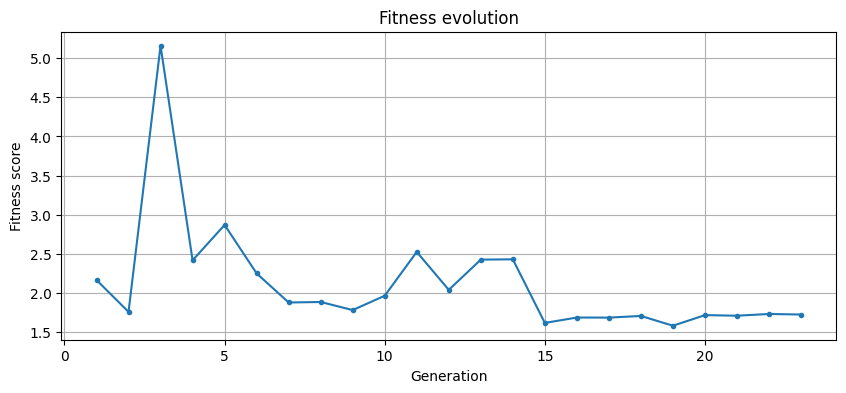

  Run  6/20  gens= 23  R²=-2.9014  RMSE=141.7071


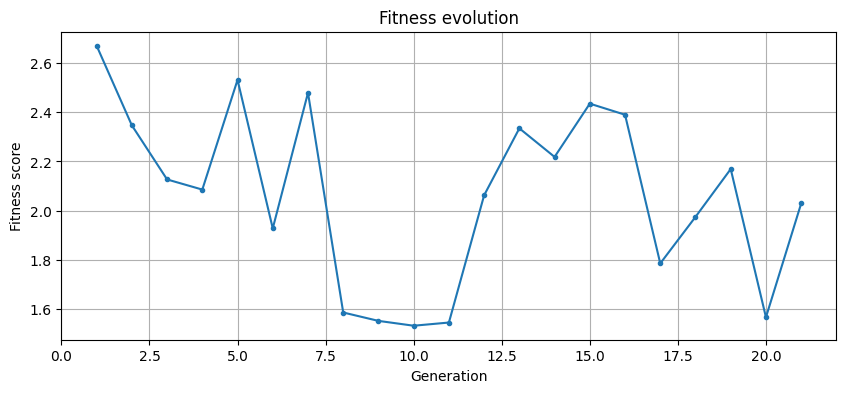

  Run  7/20  gens= 21  R²=-6.3926  RMSE=195.0659


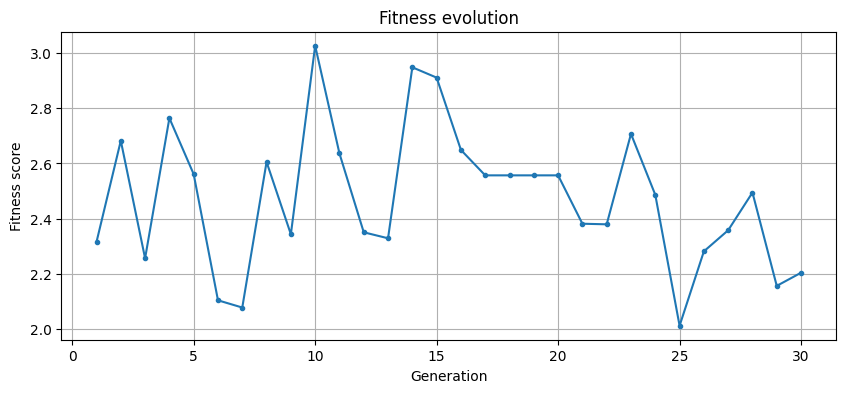

  Run  8/20  gens= 30  R²=0.6936  RMSE=39.7150


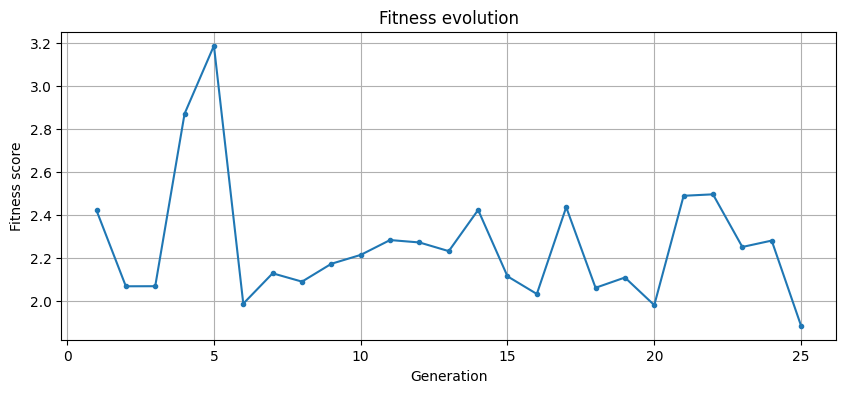

  Run  9/20  gens= 25  R²=0.9174  RMSE=20.6229


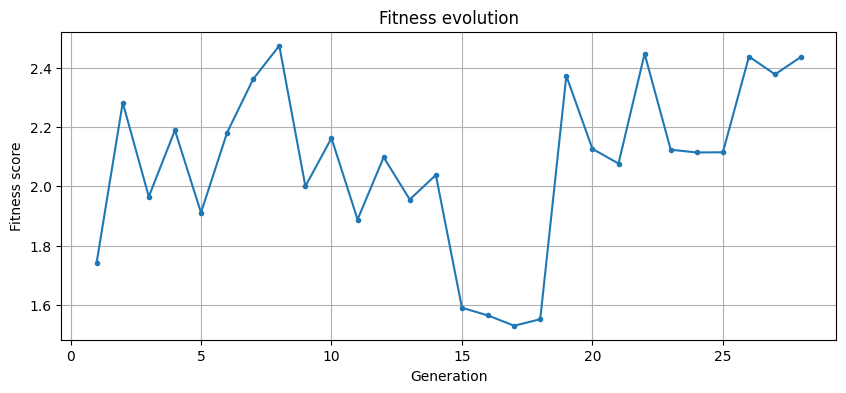

  Run 10/20  gens= 28  R²=0.6688  RMSE=41.2866


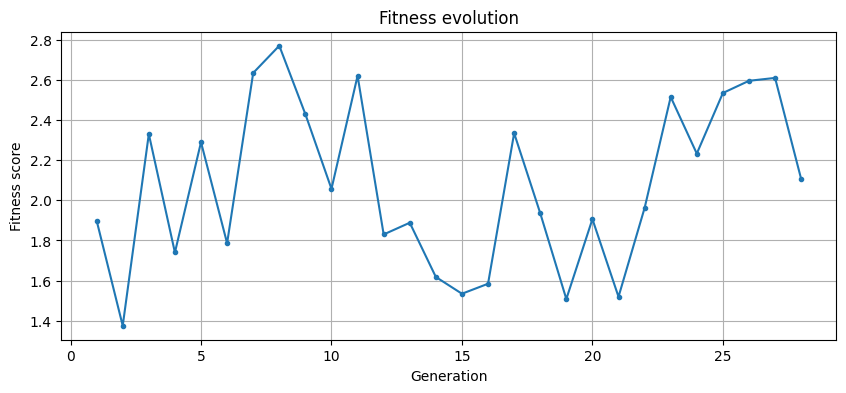

  Run 11/20  gens= 28  R²=0.4683  RMSE=52.3143


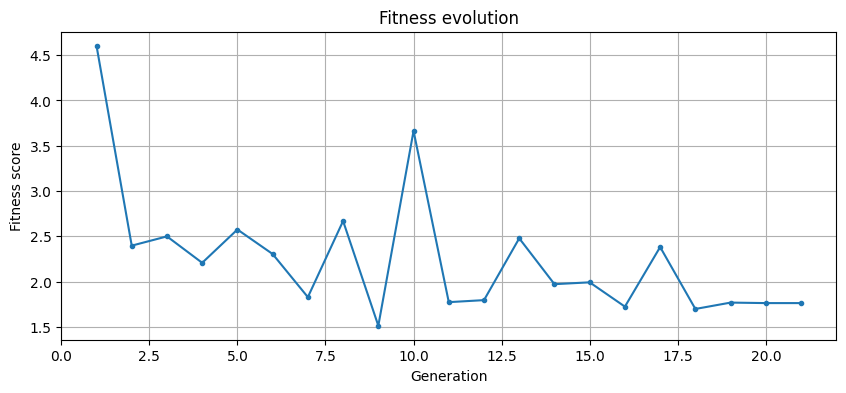

  Run 12/20  gens= 21  R²=0.8752  RMSE=25.3450


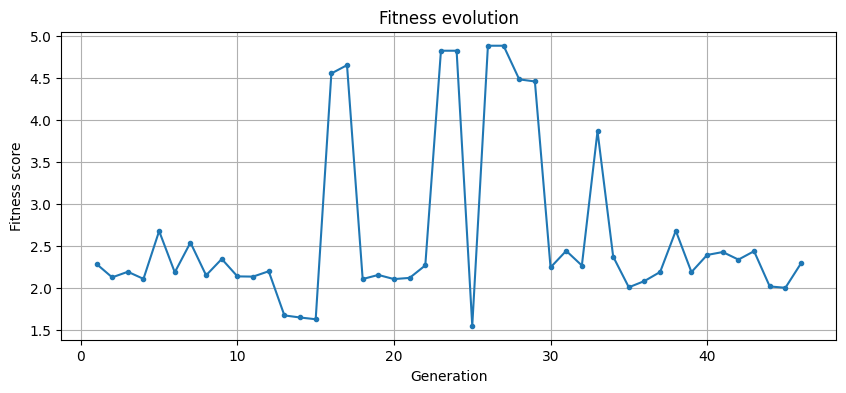

  Run 13/20  gens= 46  R²=0.7112  RMSE=38.5552


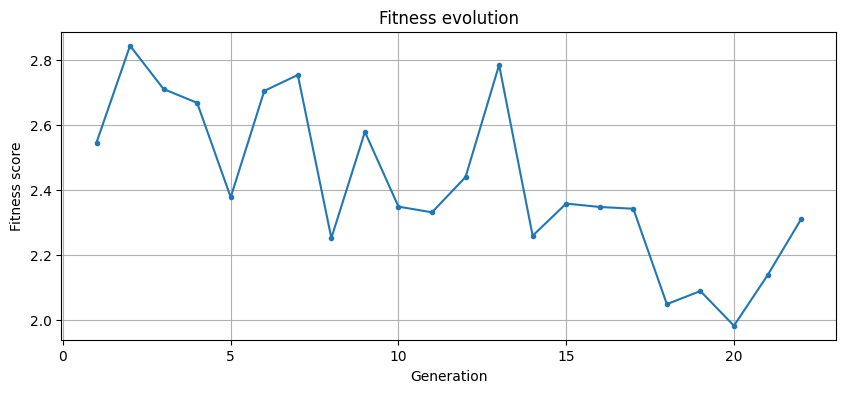

  Run 14/20  gens= 22  R²=0.2404  RMSE=62.5280


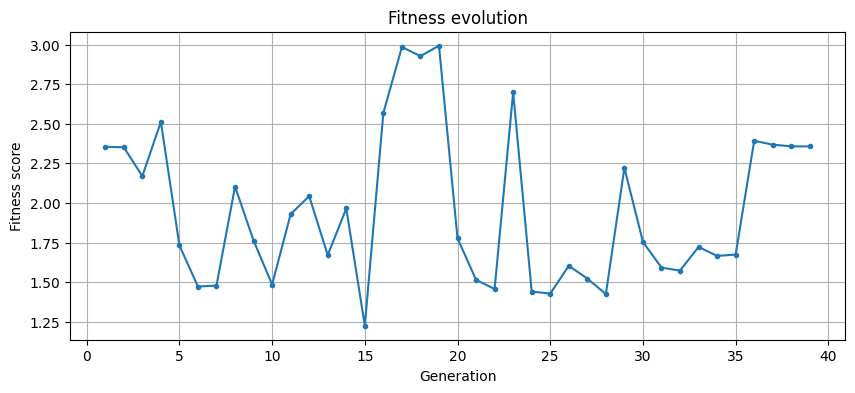

  Run 15/20  gens= 39  R²=-1.5282  RMSE=114.0735


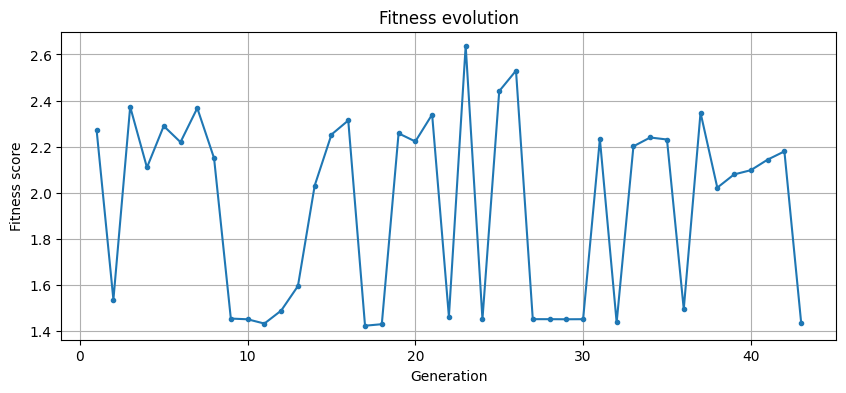

  Run 16/20  gens= 43  R²=-2.4332  RMSE=132.9338


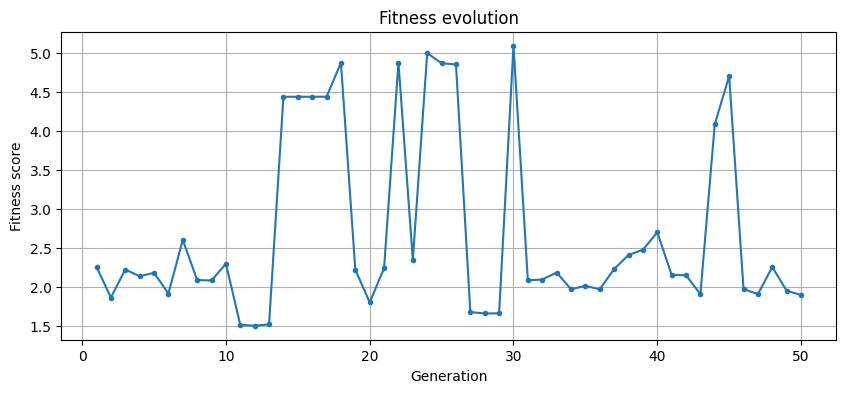

  Run 17/20  gens= 50  R²=0.7502  RMSE=35.8560


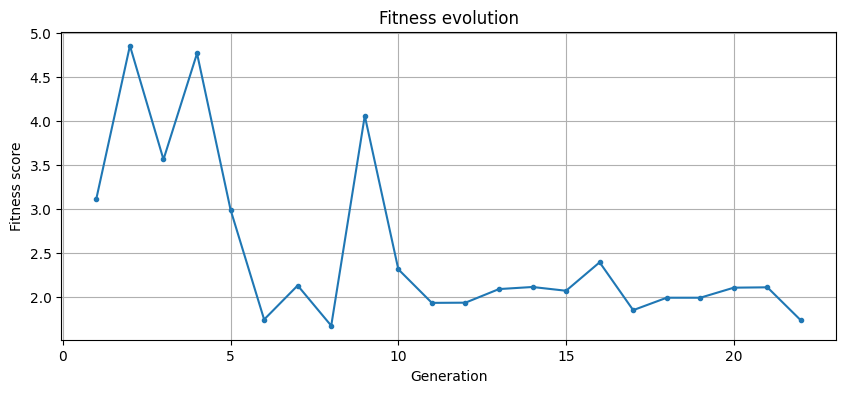

  Run 18/20  gens= 22  R²=0.5945  RMSE=45.6843


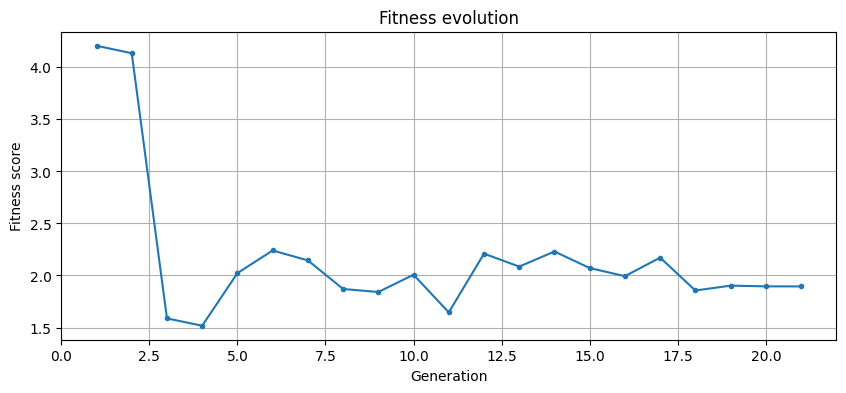

  Run 19/20  gens= 21  R²=0.4565  RMSE=52.8914


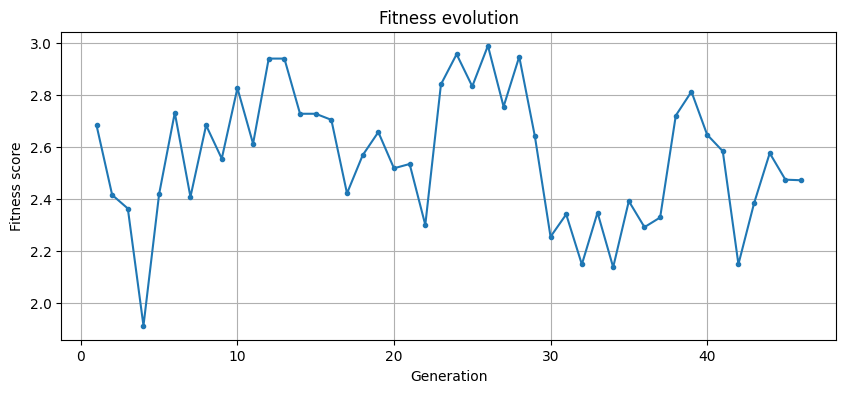

  Run 20/20  gens= 46  R²=0.4224  RMSE=54.5270

Saved → runs_random/all_results.csv
            run  n_generations  best_fitness         r2        rmse  \
count  20.00000      20.000000     20.000000  20.000000   20.000000   
mean   10.50000      33.300000      3.532328  -0.177867   64.039066   
std     5.91608      14.603893      0.966213   1.826325   45.440954   
min     1.00000      21.000000      2.474562  -6.392600   20.622909   
25%     5.75000      22.000000      2.824424   0.241381   39.425027   
50%    10.50000      28.000000      3.009799   0.588932   45.997005   
75%    15.25000      43.500000      4.594590   0.697971   62.487711   
max    20.00000      78.000000      5.160357   0.917371  195.065892   

                mse  
count     20.000000  
mean    6062.638223  
std     9400.341084  
min      425.304367  
25%     1554.584995  
50%     2115.822273  
75%     3904.714581  
max    38050.702325  


In [19]:
RUNS_DIR = 'runs_random'
n_runs = 20
pool_of_models = [SarimaModel, SVRModel, MLPModel]


print(f"Running {n_runs} independent experiments → {RUNS_DIR}/")
results = []

for i in range(n_runs):
    run_dir = os.path.join(RUNS_DIR, f'run_{i+1:02d}')
    res = run_single_experiment(pool_of_models,
    population_size=10,
    num_generations=100,
    mutation_rate=0.2,
    early_stop_patience=20,
    run_dir=run_dir)
    results.append({'run': i + 1, **res})
    print(f"  Run {i+1:>2}/{n_runs}  gens={res['n_generations']:>3}  "
          f"R²={res['r2']:.4f}  RMSE={res['rmse']:.4f}")

results_df = pd.DataFrame(results)
results_df.to_csv(os.path.join(RUNS_DIR, 'all_results.csv'), index=False)

print(f"\nSaved → {RUNS_DIR}/all_results.csv")
print(results_df.describe())


=== Shapiro-Wilk normality test ===
  R²  : W=0.5982,  p=0.0000  → non-normal
  RMSE: W=0.7473, p=0.0002  → non-normal
  MSE : W=0.5982,  p=0.0000  → non-normal

=== Descriptive statistics ===
  R²  : mean=-0.1779,  std=1.8263,  95% CI=[-1.0326, 0.6769]
  RMSE: mean=64.0391, std=45.4410, 95% CI=[42.7720, 85.3061]
  MSE : mean=6062.6382,  std=9400.3411,  95% CI=[1663.1432, 10462.1333]

=== One-sample t-test  H₀: R² ≤ 0 ===
  t=-0.4355,  p=0.665962  → fail to reject H₀


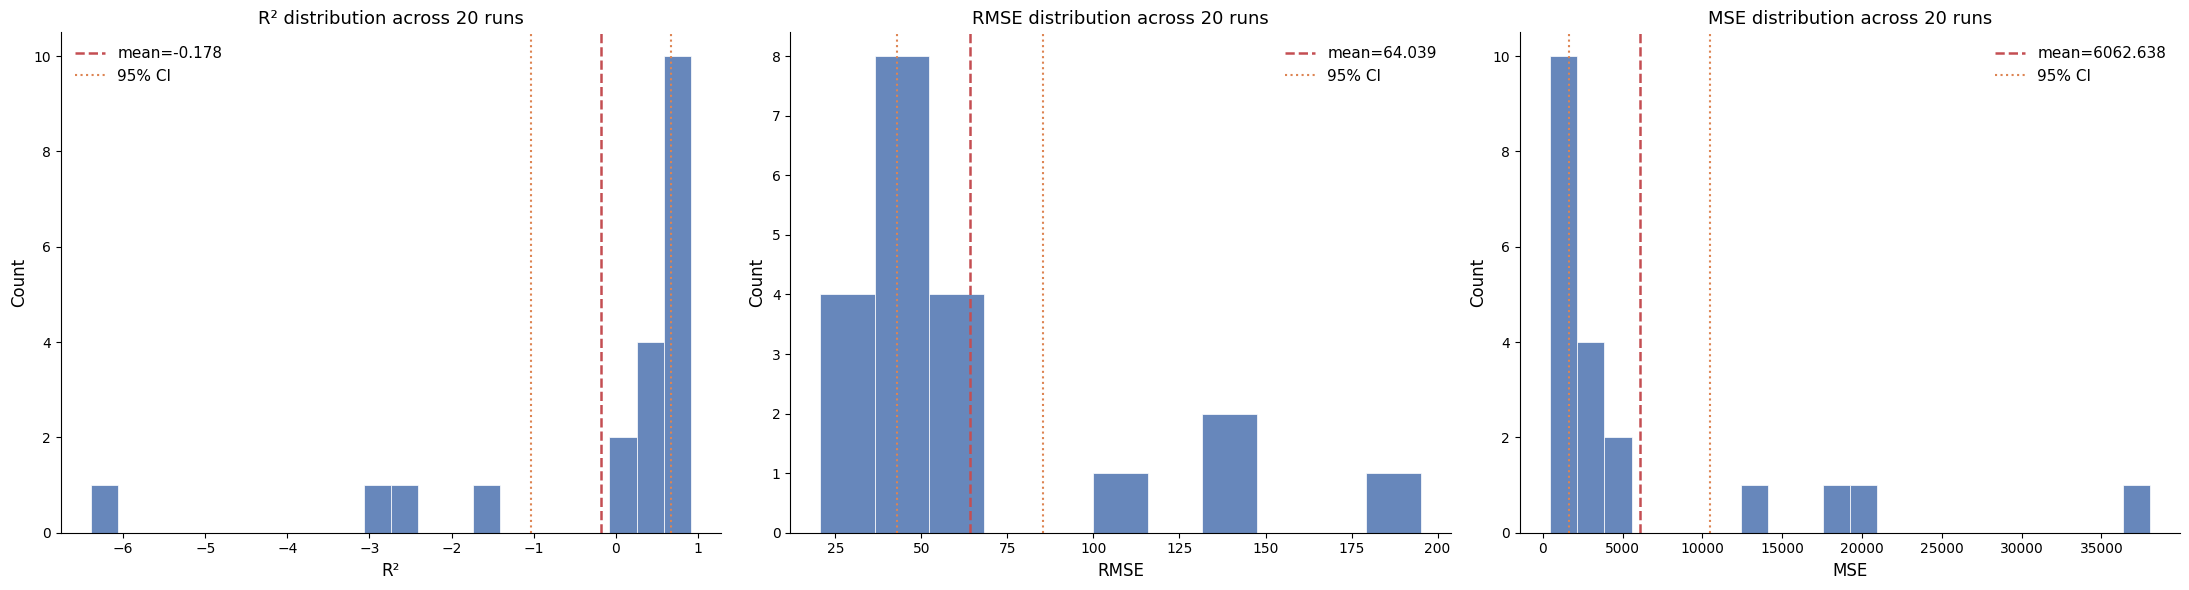

In [20]:
from scipy import stats

n = len(results_df)

# --- Normality (Shapiro-Wilk) ---
sw_r2,   p_sw_r2   = stats.shapiro(results_df['r2'])
sw_rmse, p_sw_rmse = stats.shapiro(results_df['rmse'])
sw_mse,  p_sw_mse  = stats.shapiro(results_df['mse'])

print("=== Shapiro-Wilk normality test ===")
print(f"  R²  : W={sw_r2:.4f},  p={p_sw_r2:.4f}  → {'normal' if p_sw_r2 > 0.05 else 'non-normal'}")
print(f"  RMSE: W={sw_rmse:.4f}, p={p_sw_rmse:.4f}  → {'normal' if p_sw_rmse > 0.05 else 'non-normal'}")
print(f"  MSE : W={sw_mse:.4f},  p={p_sw_mse:.4f}  → {'normal' if p_sw_mse > 0.05 else 'non-normal'}")

# --- 95% confidence intervals ---
ci_r2   = stats.t.interval(0.95, df=n-1, loc=results_df['r2'].mean(),   scale=stats.sem(results_df['r2']))
ci_rmse = stats.t.interval(0.95, df=n-1, loc=results_df['rmse'].mean(), scale=stats.sem(results_df['rmse']))
ci_mse  = stats.t.interval(0.95, df=n-1, loc=results_df['mse'].mean(),  scale=stats.sem(results_df['mse']))

print("\n=== Descriptive statistics ===")
print(f"  R²  : mean={results_df['r2'].mean():.4f},  std={results_df['r2'].std():.4f},  95% CI=[{ci_r2[0]:.4f}, {ci_r2[1]:.4f}]")
print(f"  RMSE: mean={results_df['rmse'].mean():.4f}, std={results_df['rmse'].std():.4f}, 95% CI=[{ci_rmse[0]:.4f}, {ci_rmse[1]:.4f}]")
print(f"  MSE : mean={results_df['mse'].mean():.4f},  std={results_df['mse'].std():.4f},  95% CI=[{ci_mse[0]:.4f}, {ci_mse[1]:.4f}]")

# --- One-sample t-test: H₀: mean R² ≤ 0 ---
t_stat, p_one = stats.ttest_1samp(results_df['r2'], popmean=0, alternative='greater')
print("\n=== One-sample t-test  H₀: R² ≤ 0 ===")
print(f"  t={t_stat:.4f},  p={p_one:.6f}  → {'reject H₀ (model beats baseline)' if p_one < 0.05 else 'fail to reject H₀'}")

# --- Visualisation ---
BAR_COLOR  = '#4C72B0'
MEAN_COLOR = '#C44E52'
CI_COLOR   = '#DD8452'

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for ax, col, ci, label in [
    (axes[0], 'r2',   ci_r2,   'R²'),
    (axes[1], 'rmse', ci_rmse, 'RMSE'),
    (axes[2], 'mse',  ci_mse,  'MSE'),
]:
    ax.hist(results_df[col], bins='auto', color=BAR_COLOR, edgecolor='white', linewidth=0.6, alpha=0.85)
    ax.axvline(results_df[col].mean(), color=MEAN_COLOR, linestyle='--', linewidth=1.8, label=f'mean={results_df[col].mean():.3f}')
    ax.axvline(ci[0], color=CI_COLOR, linestyle=':', linewidth=1.5, label='95% CI')
    ax.axvline(ci[1], color=CI_COLOR, linestyle=':', linewidth=1.5)
    ax.set_title(f'{label} distribution across {n} runs', fontsize=13)
    ax.set_xlabel(label, fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.legend(frameon=False, fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(RUNS_DIR, 'statistics.png'), dpi=150, bbox_inches='tight')
plt.show()
